In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the regression dataset
# The ../ tells the notebook to step out of the 'notebook' folder and into 'dataset'
df = pd.read_csv('../dataset/california_housing_test.csv')

print("Environment Ready! Data Loaded. Shape:", df.shape)
df.head()

Environment Ready! Data Loaded. Shape: (3000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [3]:
# 1. Removing duplicate records
df = df.drop_duplicates()

# 2. Handling missing values (fills with median to stay safe)
df = df.fillna(df.median())

# 3. Removing irrelevant features
# Dropping coordinates to focus on physical house attributes
df = df.drop(columns=['longitude', 'latitude'])

# 4. Outlier Treatment (IQR Method)
# We cap 'total_rooms' and 'population' to prevent extreme values from skewing the model
for col in ['total_rooms', 'population']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("Data Cleaning Complete!")
print("New Shape:", df.shape)
df.describe()

Data Cleaning Complete!
New Shape: (3000, 7)


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,28.845333,2422.438667,529.950667,1334.742458,489.91200,3.807272,205846.27500
std,12.555396,1413.020289,415.654368,769.839011,365.42271,1.854512,113119.68747
min,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,52.000000,5721.000000,5419.000000,3186.875000,4930.00000,15.000100,500001.00000


In [4]:
# Separate Features (X) from Target (y)
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Mandatory for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled. Ready for Model Training!")

Data split and scaled. Ready for Model Training!


In [5]:
# Initialize the models as per Assignment 4 requirements
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Training and Evaluation Loop
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    predictions = model.predict(X_test_scaled)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {"MAE": mae, "R2 Score": r2}
    print(f"--- {name} ---")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score (Accuracy): {r2:.4f}\n")

# Simple Summary
print("FINAL COMPARISON:")
for model, metrics in results.items():
    print(f"{model}: R2 = {metrics['R2 Score']:.4f}")

--- Linear Regression ---
Mean Absolute Error: 56374.70
R2 Score (Accuracy): 0.5441

--- Decision Tree ---
Mean Absolute Error: 67498.37
R2 Score (Accuracy): 0.3149

--- Random Forest ---
Mean Absolute Error: 50391.94
R2 Score (Accuracy): 0.6254

FINAL COMPARISON:
Linear Regression: R2 = 0.5441
Decision Tree: R2 = 0.3149
Random Forest: R2 = 0.6254


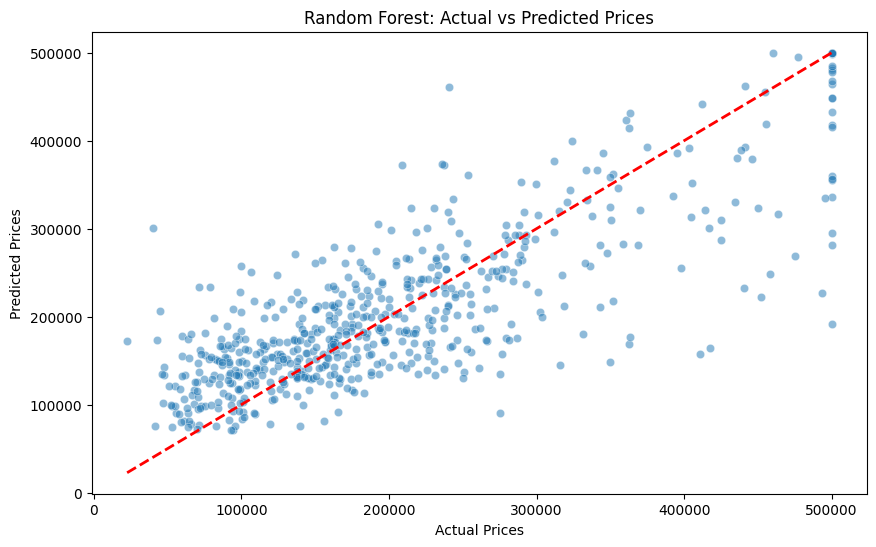

In [6]:
# Visualizing the Best Model's Predictions (usually Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()